<div class='alert alert-block alert-info"'>
<h1> Application to plant senescence genetic marker
identification :</h1>

<h4> Estimation and variable selection in an Mixed-effect models </h4>

In [2]:
import sdg4varselect.plot as sdgplt
import jax.numpy as jnp
import jax.random as jrd

### Joint Model Specification

$$ \left\{\begin{array}{rll}
            h(t|U_i) 
            &=h_{0}(t) \exp(\beta^T U_i + \alpha m(t,\varphi_i))
            \\ Y_{i,j} &= m(t_j; \varphi_i) + \varepsilon_{i,j}
            \\ \varphi_i \sim \mathcal N(\mu, \Gamma)   
            & ; ~\varepsilon_{i,j} \sim \mathcal N(0,\sigma^2).             
        \end{array}\right. ~ \forall i \in\{1,...,N\}, j\in\{1,...,J\}$$

where : $h_{0}(t)= b a^{-b} t^{b-1}$ with $a=80$ and $b=35$

#### NLMEM Specification

First, let's define the model with the abstract object AbstractMixedEffectsModel. We want to define the following logisitc models :

$$ \left\{\begin{array}{rll}
            Y_{i,j} &= m(t_{i,j}; \varphi_i) + \varepsilon_{i,j}
            \\ \varphi_i \sim \mathcal N(\mu, \Gamma)   
            & ; ~\varepsilon_{i,j} \sim \mathcal N(0,\sigma^2).             
        \end{array}\right. ~ \forall i \in\{1,...,N\}, j\in\{1,...,J\}$$

where : $m(t_{i,j}; \varphi) = \frac{\varphi_{1,i}}{1+\exp\left(\frac{\varphi_{2,i}-t_{i,j}}{\tau} \right)}$ 

In [3]:
# pylint: disable=C0116, W0221
import functools
from jax import jit
import parametrization_cookbook.jax as pc

from sdg4varselect.models import (
    AbstractMixedEffectsModel,
    AbstractHDModel,
    cov_simulation,
)


class LogisticMixedEffectsModel(AbstractMixedEffectsModel):
    """define a logistic mixed effects model"""

    def __init__(self, N=1, J=1, **kwargs):
        AbstractMixedEffectsModel.__init__(
            self,
            N=N,
            J=J,
            me_name=["phi1", "phi2"],
            **kwargs,
        )

        self.init()

    @property
    def name(self):
        """return a str called name, based on the parameter of the model"""
        return f"LogisticMEM_N{self.N}_J{self.J}"

    def init(self):
        """here you define the parametrization of the model
        and don't forget to call the mother init function at the end"""

        self._parametrization = pc.NamedTuple(
            mean_latent=pc.NamedTuple(
                asymptotic=pc.RealPositive(scale=100),
                inflexion=pc.Real(loc=100, scale=100),
            ),
            tau=pc.RealPositive(scale=100),
            cov_latent=pc.MatrixDiagPosDef(dim=2, scale=(200, 200)),
            var_residual=pc.RealPositive(scale=100),
        )

        AbstractMixedEffectsModel.init(self)

    # ============================================================== #
    @functools.partial(jit, static_argnums=0)
    def mixed_effect_function(
        self,
        params,
        times: jnp.ndarray,  # shape = (J,) [None, :]
        phi1: jnp.ndarray,  # shape = (N,) [:,None]
        phi2: jnp.ndarray,  # shape = (N,) [:,None]
        **kwargs,
    ) -> jnp.ndarray:  # shape = (N,J)
        """logistic_curve
        phi1 = asymptotic
        phi2 = inflexion
        """

        out = phi1[:, None] / (1 + jnp.exp(-(times - phi2[:, None]) / params.tau))
        assert out.shape == times.shape
        return out

    # ============================================================== #

    def sample(
        self,
        params_star,
        prngkey,
        **kwargs,
    ):
        """Sample one data set for the model"""

        (
            prngkey_time,
            prngkey_mem,
        ) = jrd.split(prngkey, num=2)

        # === nlmem_simulation() === #
        time = jnp.linspace(100, 1500, self.J)
        time = jnp.tile(time, (self.N, 1))
        time += 10 * jrd.uniform(prngkey_time, minval=-2, maxval=2, shape=time.shape)

        obs, sim = AbstractMixedEffectsModel.sample(
            self, params_star, prngkey_mem, mem_obs_time=time
        )

        return {"mem_obs_time": time} | obs, sim

joint model with coxModel is all ready implement in sdg4varselect for all MixedEffectsModel

In [15]:
from sdg4varselect.models import WeibullCoxJM


def jointModel(N, J, P):
    return WeibullCoxJM(
        mem=LogisticMixedEffectsModel(N=N, J=J), P=P, alpha_scale=0.001, a=800, b=10
    )

In [41]:
import pandas as pd
from sdg4varselect.outputs import TestResults

results = TestResults(
    [
        TestResults.load(
            jointModel(400, 15, 500), root="files", filename_add_on=f"S(1, 100)"
        ),
        TestResults.load(
            jointModel(400, 15, 500), root="files", filename_add_on=f"S(1, 100)"
        ),
    ],
    [
        {"N": 400, "J": 15, "P": 500},
        {"N": 400, "J": 15, "P": 500},
    ],
)
nrun_to_keep = min([len(t) for t in results])
results = TestResults(
    [t.reduce_number_run(nrun_to_keep) for t in results], results.config
)

print(f"chrono = {[str(t.chrono) for t in results]}")
print([len(t) for t in results])


pd.DataFrame(
    [
        [str(t.chrono / t.total_number_res) for t in results],
        [str(t.chrono / len(t[0])) for t in results],
    ],
    index=[
        "by fit",
        f"by estimation ( {results[0].total_number_res/len(results[0])} fits)",
    ],
    columns=[f'N = {c["N"]}, P = {c["P"]}' for c in results.config],
).T

files/WCoxMemJM_N400_J15_P500_S(1, 100) LOADED !
files/WCoxMemJM_N400_J15_P500_S(1, 100) LOADED !
chrono = ['6 days, 7:31:22.035656', '6 days, 7:31:22.035656']
[100, 100]


,by fit,by estimation ( 20.0 fits)
"N = 400, P = 500",0:04:32.741018,15:09:08.203566
"N = 400, P = 500",0:04:32.741018,15:09:08.203566


In [28]:
myModel = jointModel(200, 15, P=max([c["P"] for c in results.config]))

p_star = myModel.new_params(
    mean_latent={"asymptotic": 200, "inflexion": 500},
    tau=150,
    cov_latent=jnp.diag(jnp.array([40, 100])),
    var_residual=10,
    alpha=0.05,
    beta=jnp.concatenate(
        [jnp.array([-3, -2, 2, 3]), jnp.zeros(shape=(myModel.P - 4,))]
    ),
)

Vérification de la réparition des estimations par rapport à la vraissemblance

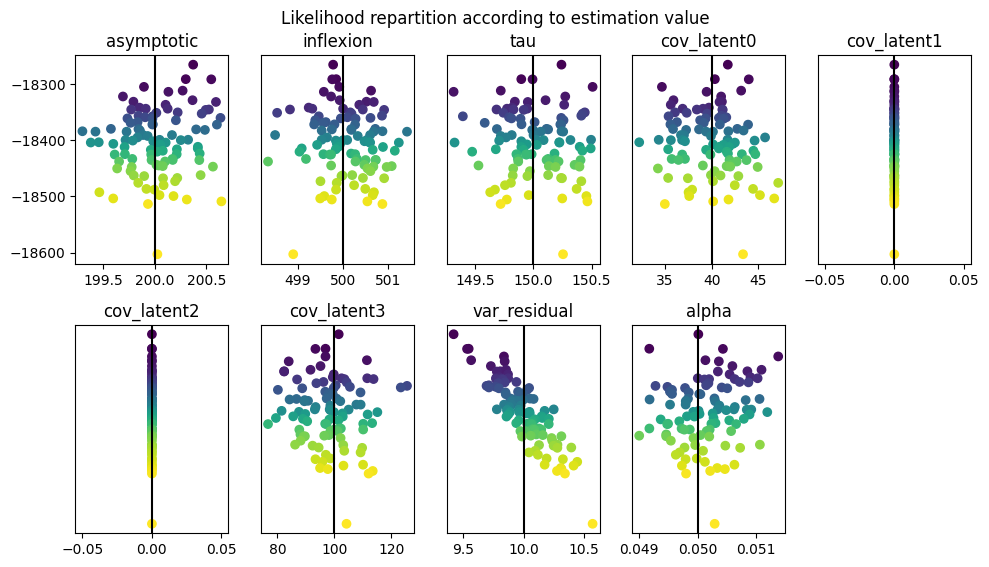

In [20]:
fig = sdgplt.figure(height=8, width=10)
results[-1].sort()

_ = sdgplt.scatter_estimation(
    results[-1].last_theta[:, 1, : myModel.DIM_LD].T,
    results[-1].likelihood[:, 1],
    vline=myModel.hstack_params(p_star)[: myModel.DIM_LD],
    labels=myModel.params_names[: myModel.DIM_LD],
    nrows=3,
    ncols=5,
    fig=fig,
)

fig.tight_layout()

_ = fig.suptitle("Likelihood repartition according to estimation value", y=1.01)

Regularization path check

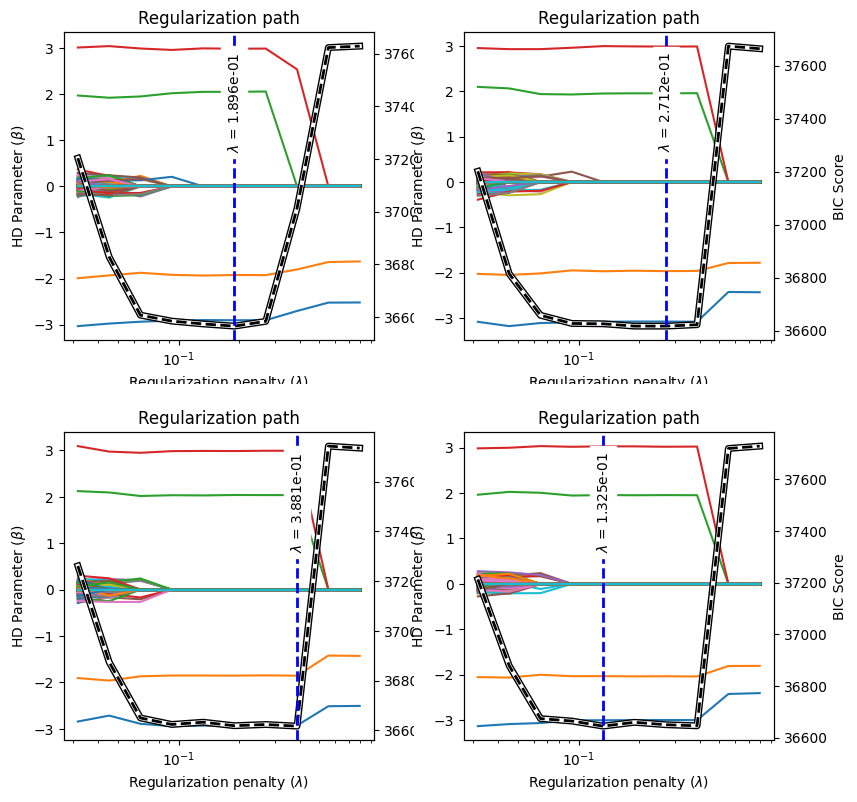

In [23]:
fig = sdgplt.figure(8, 8)
subfigs = fig.subfigures(2, 2, wspace=0.07)

for i, subfigsarr in enumerate(subfigs):
    for j, subfig in enumerate(subfigsarr):
        sdgplt.plot_reg_path(
            reg_res=results[-1][i * subfigs.shape[0] + j],
            dim_ld=myModel.DIM_LD,
            fig=subfig,
        )

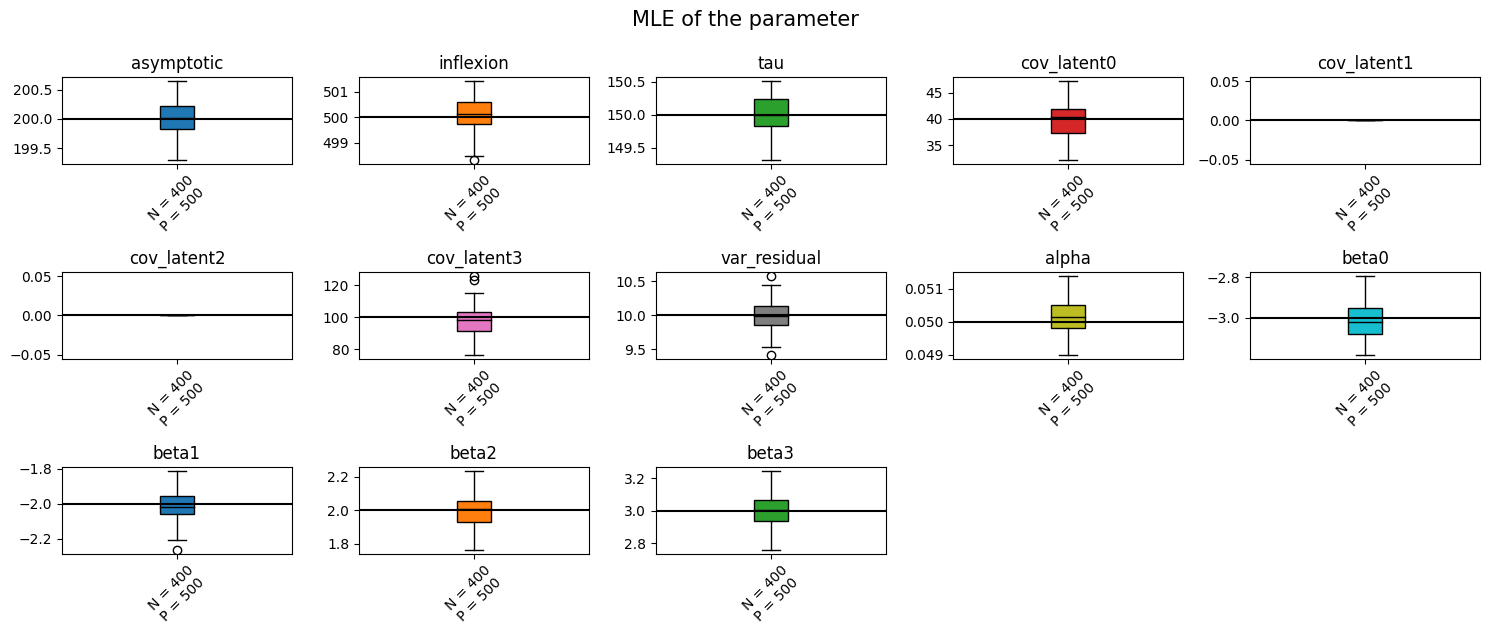

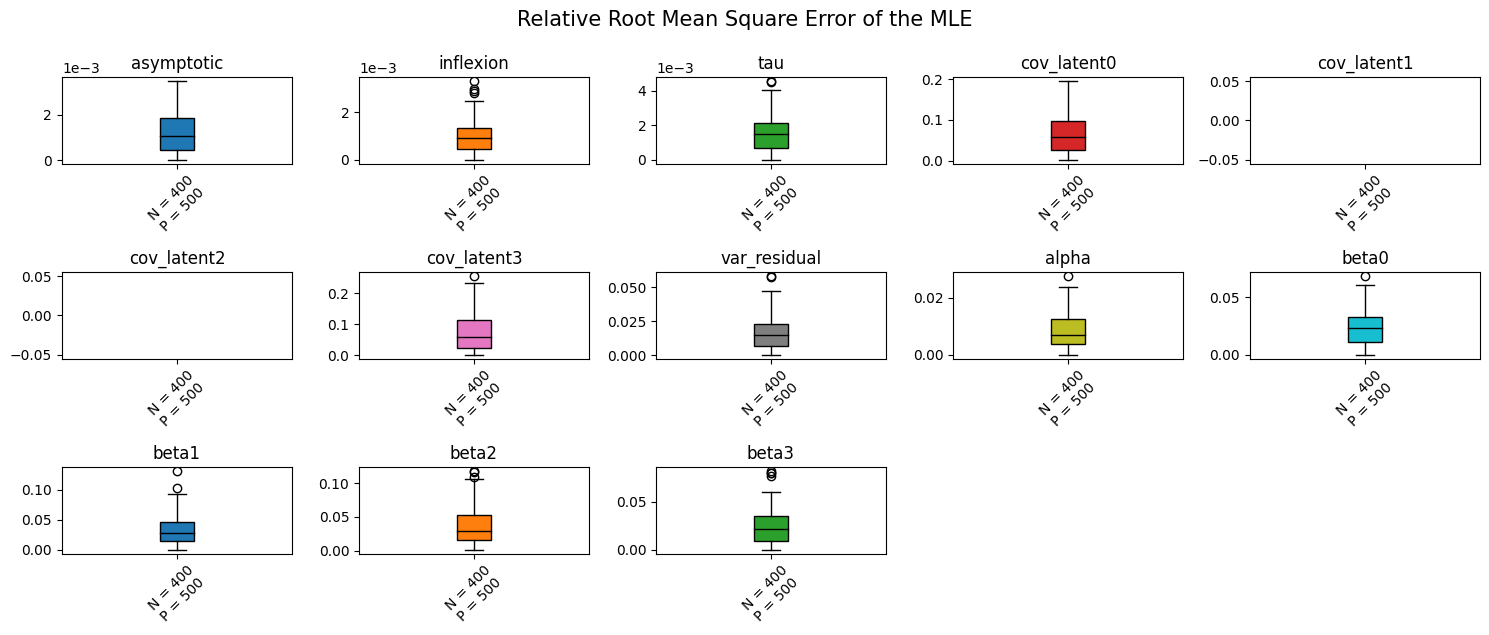

In [22]:
scenarios_labels = [
    f"{n}\n{p}"
    for n, p in zip(
        results.get_scenarios_labels("N"), results.get_scenarios_labels("P")
    )
]
x = results.last_theta[:, :, 1, : myModel.DIM_LD + 4]
fig = sdgplt.boxplot_estimation(
    x=x.T,
    hline=myModel.hstack_params(p_star)[: myModel.DIM_LD + 4],
    xlabels=scenarios_labels,
    title=myModel.params_names[: myModel.DIM_LD + 4],
    nrows=3,
    ncols=5,
    fig=sdgplt.figure(height=6, width=15),
)

for ax in fig.axes:
    ax.tick_params(axis="x", labelrotation=45)
fig.tight_layout()
_ = fig.suptitle("MLE of the parameter", fontsize=15, y=1.05)

x = jnp.abs((1 - x / myModel.hstack_params(p_star)[: myModel.DIM_LD + 4]))
fig = sdgplt.boxplot_estimation(
    x=x.T,
    xlabels=scenarios_labels,
    title=myModel.params_names[: myModel.DIM_LD + 4],
    nrows=3,
    ncols=5,
    fig=sdgplt.figure(height=6, width=15),
)

for ax in fig.axes:
    ax.tick_params(axis="x", labelrotation=45)
fig.tight_layout()
_ = fig.suptitle("Relative Root Mean Square Error of the MLE", fontsize=15, y=1.05)

In [32]:
last_theta_estim = results[-1].last_theta[:, 1]

sdgplt.get_dataframe_results(
    last_theta_estim, myModel.hstack_params(p_star), myModel.params_names
).style.format(
    {
        "real value": "{:.1f}".format,
        "mean": "{:.2f}".format,
        "variance": "{:.3f}".format,
        "rmse": "{:.4f}".format,
        "rrmse": "{:.1%}".format,
    }
)

,real value,mean,variance,rmse,rrmse
asymptotic,200.0,200.03,0.091,0.3027,0.2%
inflexion,500.0,500.08,0.381,0.6234,0.1%
tau,150.0,150.02,0.076,0.2763,0.2%
cov_latent0,40.0,40.00,9.642,3.1052,7.8%
cov_latent3,100.0,98.18,87.711,9.5416,9.5%
var_residual,10.0,10.00,0.044,0.2094,2.1%
alpha,0.1,0.05,0.000,0.0005,1.1%
beta0,-3.0,-3.01,0.008,0.0878,2.9%
beta1,-2.0,-2.01,0.007,0.0839,4.2%
beta2,2.0,1.99,0.009,0.0972,4.9%


### Variable selection numerical proof

In [51]:
def get_support_star(x, x_star):
    xx_star = jnp.tile(p_star.beta, reps=x.shape[:-1] + (1,))
    return jnp.where(jnp.isnan(x), jnp.nan, xx_star != 0)


support_star = get_support_star(
    results.last_theta[:, :, -1, myModel.DIM_LD :], p_star.beta
)
print(support_star.shape)


def get_support(x, x_star):
    if len(x.shape) > 1:
        return jnp.array([get_support(xx, x_star) for xx in x])

    return jnp.where(jnp.isnan(x), jnp.nan, x != 0)


multi_support = get_support(results.last_theta[:, :, -1, myModel.DIM_LD :], p_star.beta)
print(multi_support.shape)

(2, 100, 500)
(2, 100, 500)


In [54]:
x = jnp.array([sensitivity, specificity, accuracy, L1, L2])
x.shape

(5, 2, 100)

(10, 100)

In [65]:
ds = jnp.abs(multi_support - support_star)
# TP/total P
TP = jnp.nansum(ds[:, :, :3], axis=-1)
sensitivity = 1 - jnp.nanmean(ds[:, :, :3], axis=-1)
# TN / total N
TN = jnp.nansum(ds[:, :, 3:], axis=-1)
specificity = 1 - jnp.nanmean(ds[:, :, 3:], axis=-1)
# (TP+TN)/dim
accuracy = 1 - jnp.nansum(ds, axis=-1)
accuracy = 1 - jnp.nanmean(ds, axis=-1)

dx = jnp.abs(results.last_theta[:, :, -1, myModel.DIM_LD :] - p_star.beta)
L1 = jnp.nansum(dx, axis=-1)
L2 = jnp.sqrt(jnp.nansum(dx**2, axis=-1))

x = jnp.array([sensitivity, specificity, accuracy, L1, L2])
df = [
    pd.DataFrame(
        x[:, i],  # .mean(axis=-1),
        index=["sensitivity", "specificity", "accuracy", "L1", "L2"],
        # columns=[f'N = {c["N"]}, P = {c["P"]}' for c in results.config],
    ).T
    for i in range(x.shape[1])
]
# .T.style.format(
#     {
#         "sensitivity": "{:.1%}".format,
#         "specificity": "{:.1%}".format,
#         "accuracy": "{:.1%}".format,
#         "L1": "{:.1f}".format,
#         "L2": "{:.1f}".format,
#     }
# )

pd.concat(df, keys=scenarios_labels, axis=1)

a                                                     
                   0         1         2         3         4         5    
sensitivity  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  \
specificity  0.995976  1.000000  1.000000  1.000000  1.000000  1.000000   
accuracy     0.996000  1.000000  1.000000  1.000000  1.000000  1.000000   
L1           0.923018  0.327417  0.441187  0.400267  0.216876  0.270737   
L2           0.453683  0.226883  0.244935  0.211996  0.123895  0.142052   
sensitivity  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000   
specificity  0.995976  1.000000  1.000000  1.000000  1.000000  1.000000   
accuracy     0.996000  1.000000  1.000000  1.000000  1.000000  1.000000   
L1           0.923018  0.327417  0.441187  0.400267  0.216876  0.270737   
L2           0.453683  0.226883  0.244935  0.211996  0.123895  0.142052   

                                                     ...        b             
                   6         7         8         9   ...       90        91   
sensitivity  1.000000  1.000000  1.000000  1.000000  ...  1.00000  1.000000  \
specificity  0.995976  1.000000  1.000000  1.000000  ...  1.00000  1.000000   
accuracy     0.996000  1.000000  1.000000  1.000000  ...  1.00000  1.000000   
L1           0.891901  0.208284  0.237866  0.208101  ...  0.37818  0.358099   
L2           0.487255  0.133036  0.150791  0.122216  ...  0.20431  0.211087   
sensitivity  1.000000  1.000000  1.000000  1.000000  ...  1.00000  1.000000   
specificity  0.995976  1.000000  1.000000  1.000000  ...  1.00000  1.000000   
accuracy     0.996000  1.000000  1.000000  1.000000  ...  1.00000  1.000000   
L1           0.891901  0.208284  0.237866  0.208101  ...  0.37818  0.358099   
L2           0.487255  0.133036  0.150791  0.122216  ...  0.20431  0.211087   

                                                                          
                   92        93        94        95        96        97   
sensitivity  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  \
specificity  0.997988  1.000000  1.000000  1.000000  1.000000  1.000000   
accuracy     0.998000  1.000000  1.000000  1.000000  1.000000  1.000000   
L1           0.484013  0.305502  0.325232  0.354374  0.178716  0.156211   
L2           0.278746  0.163038  0.250079  0.193077  0.101719  0.138848   
sensitivity  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000   
specificity  0.997988  1.000000  1.000000  1.000000  1.000000  1.000000   
accuracy     0.998000  1.000000  1.000000  1.000000  1.000000  1.000000   
L1           0.484013  0.305502  0.325232  0.354374  0.178716  0.156211   
L2           0.278746  0.163038  0.250079  0.193077  0.101719  0.138848   

                                
                   98       99  
sensitivity  1.000000  1.00000  
specificity  1.000000  1.00000  
accuracy     1.000000  1.00000  
L1           0.354791  0.27706  
L2           0.231816  0.19625  
sensitivity  1.000000  1.00000  
specificity  1.000000  1.00000  
accuracy     1.000000  1.00000  
L1           0.354791  0.27706  
L2           0.231816  0.19625  

[10 rows x 200 columns]

[[0.84999996 0.14999999]]


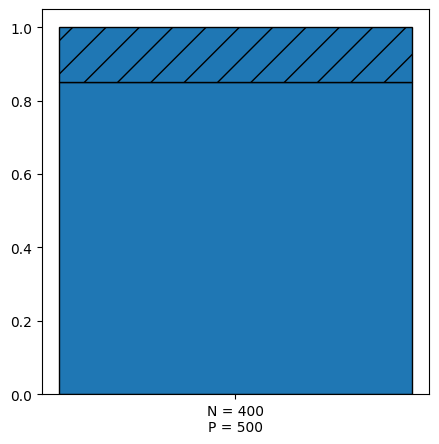

In [30]:
all_component = jnp.nansum(jnp.abs(multi_support - support_star), axis=-1) == 0
first_component = (multi_support == support_star)[:, :, :3].mean(axis=-1) == 1
overselection = jnp.logical_and(first_component, jnp.logical_not(all_component))

score_support = jnp.array([all_component, overselection]).mean(axis=-1).T
print(score_support)

labels = ["Exact", "Over-selection"]
hatchs = ["", "/"]

ax = sdgplt.get_ax(5, 5)
for i in range(score_support.shape[0]):
    for j in range(len(labels)):
        ax.bar(
            scenarios_labels[i],
            score_support[i, j],
            label=labels[j],
            bottom=score_support[i, :j].sum(axis=0),
            color=f"C{0}",
            edgecolor="black",
            width=0.1,
            hatch=hatchs[j],
        )

### Data Generation
Then we can generate a data set with $N=2000$ individuals and $J=15$ observation time per individuals

In [6]:
p_star = myModel.new_params(
    mean_latent={"asymptotic": 200, "inflexion": 500},
    tau=150,
    cov_latent=jnp.diag(jnp.array([40, 100])),
    var_residual=10,
    alpha=0.05,
    beta=jnp.concatenate(
        [jnp.array([-3, -2, 2, 3]), jnp.zeros(shape=(myModel.P - 4,))]
    ),
)


mylbd_set = 10 ** jnp.linspace(-1.5, -0.1, num=10)  # P = 500

seed = 0
myprngkey = jrd.PRNGKey(seed)
print(f"seed = {seed}, prngkey = {myprngkey}")


mydata, _ = myModel.sample(p_star, myprngkey, weibull_censoring_loc=7700)

seed = 0, prngkey = [0 0]
0.00011473894119262695


And plot the results

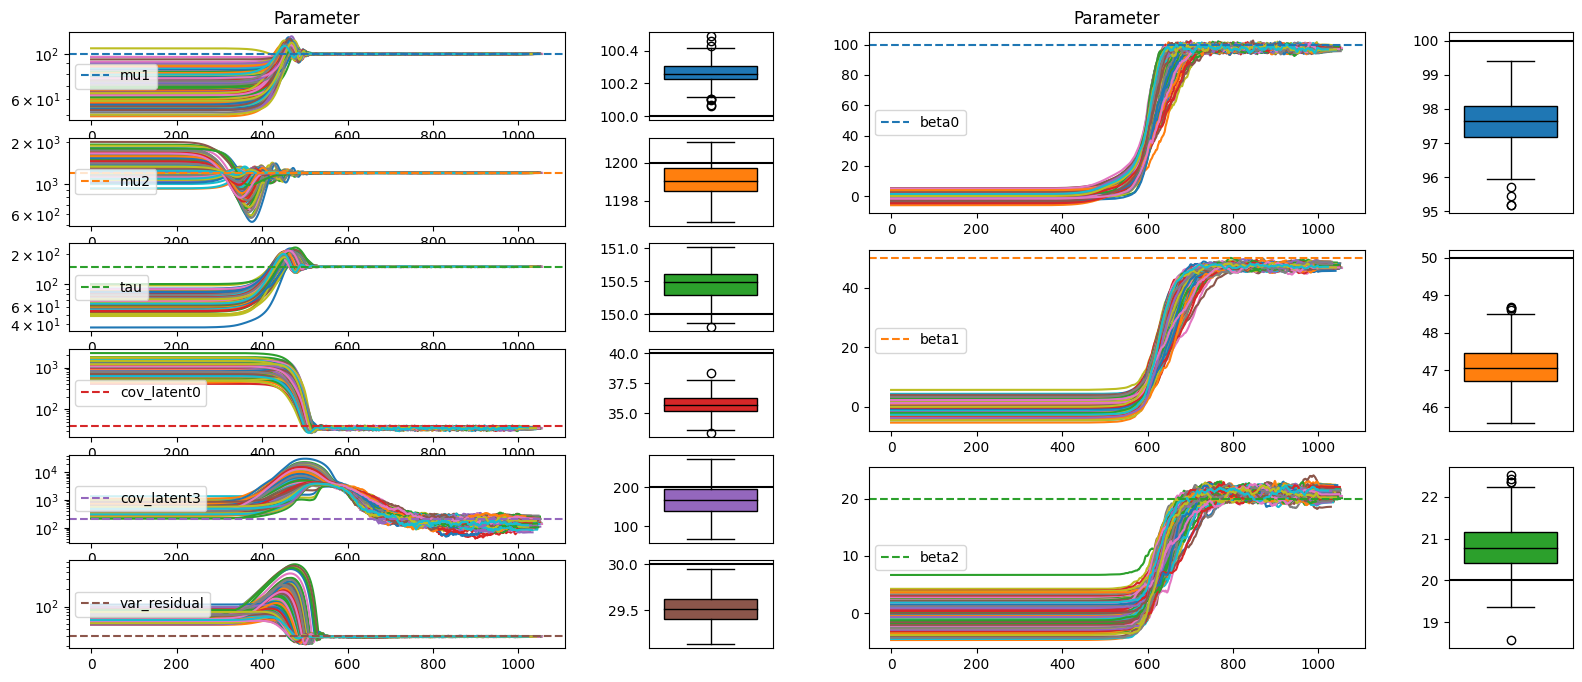

In [24]:
def plot_estimation(multi_estim, id_to_plot=[0, 1, 2, 3, 6, 7]):
    fig = sdgplt.figure(8, 16)
    subfigs = fig.subfigures(1, 4, wspace=0.07, width_ratios=[4, 1, 4, 1])
    # subfigs = subfigs.reshape((subfigs.size,))

    _ = sdgplt.plot_theta(
        multi_estim,
        dim_ld=myModel.DIM_LD,
        params_star=myModel.hstack_params(p_star),
        params_names=myModel.params_names,
        id_to_plot=id_to_plot,
        log_scale=True,
        fig=subfigs[0],
    )

    f = sdgplt.boxplot_estimation(
        # multi_estim.last_theta.T,
        x=multi_estim.last_theta.T[id_to_plot,],
        hline=myModel.hstack_params(p_star)[id_to_plot,],
        # xlabels=myModel.params_names,
        nrows=len(id_to_plot),
        ncols=1,
        fig=subfigs[1],
    )

    for ax in f.axes:
        ax.set_xlim(1 + 0.1 * jnp.array([-1, 1]))
        ax.get_yaxis().get_major_formatter().set_useOffset(False)
        ax.ticklabel_format(style="plain", axis="y")

    _ = sdgplt.plot_theta_hd(
        multi_estim,
        dim_ld=myModel.DIM_LD,
        params_star=myModel.hstack_params(p_star),
        params_names=myModel.params_names,
        fig=subfigs[2],
    )

    f = sdgplt.boxplot_estimation(
        multi_estim.last_theta.T[myModel.DIM_LD :],
        hline=myModel.hstack_params(p_star)[myModel.DIM_LD :],
        # xlabels=myModel.params_names[myModel.DIM_LD :],
        nrows=myModel.P,
        ncols=1,
        fig=subfigs[3],
    )
    for ax in f.axes:
        ax.set_xlim(1 + 0.1 * jnp.array([-1, 1]))
        ax.get_yaxis().get_major_formatter().set_useOffset(False)
        ax.ticklabel_format(style="plain", axis="y")

    return fig


fig = plot_estimation(multi_res)
# fig.tight_layout()

In [25]:
sdgplt.get_dataframe_results(
    multi_res.last_theta, myModel.hstack_params(p_star), myModel.params_names
).style.format(
    {
        "real value": "{:.1f}".format,
        "mean": "{:.2f}".format,
        "variance": "{:.3f}".format,
        "rmse": "{:.4f}".format,
        "rrmse": "{:.1%}".format,
    }
)

,real value,mean,variance,rmse,rrmse
mu1,100.0,100.26,0.005,0.2677,0.3%
mu2,1200.0,1199.10,0.651,1.2112,0.1%
tau,150.0,150.45,0.054,0.5071,0.3%
cov_latent0,40.0,35.69,0.704,4.3926,11.0%
cov_latent1,0.0,-16.97,28.872,17.8042,inf%
cov_latent2,0.0,-16.97,28.872,17.8042,inf%
cov_latent3,200.0,166.65,1709.051,53.1165,26.6%
var_residual,30.0,29.53,0.026,0.4967,1.7%
beta0,100.0,97.58,0.551,2.5271,2.5%
beta1,50.0,47.12,0.345,2.9361,5.9%


## Numerical Proof

### Sans correlation entre les effets aléatoires

On définit un modèle avec un parametrisation spécifique pour la matrice de variance-covariance pour les variables latentes, on utilisante MatrixDiagPosDef pour forcer la forme diagonale définit positive.

In [34]:
class HDLogisticMEM_not_corr(HDLogisticMixedEffectsModel):
    def __init__(self, N=1, J=1, P=1):
        HDLogisticMixedEffectsModel.__init__(self, N=N, J=J, P=P)

    def init(self):
        """here you define the parametrization of the model
        and don't forget to call the mother init function at the end"""
        self._parametrization = pc.NamedTuple(
            mean_latent=pc.NamedTuple(
                mu1=pc.RealPositive(scale=100),
                mu2=pc.RealPositive(scale=2000),
            ),
            tau=pc.RealPositive(scale=100),
            cov_latent=pc.MatrixDiagPosDef(dim=2, scale=(2000, 2000)),
            var_residual=pc.RealPositive(scale=100),
            beta=pc.Real(scale=10, shape=(self.P,)),
        )
        AbstractHDModel.init_dim(self)


mynotCorrModel = HDLogisticMEM_not_corr(N=200, J=15, P=3)


Computation time = 0:00:54.332622


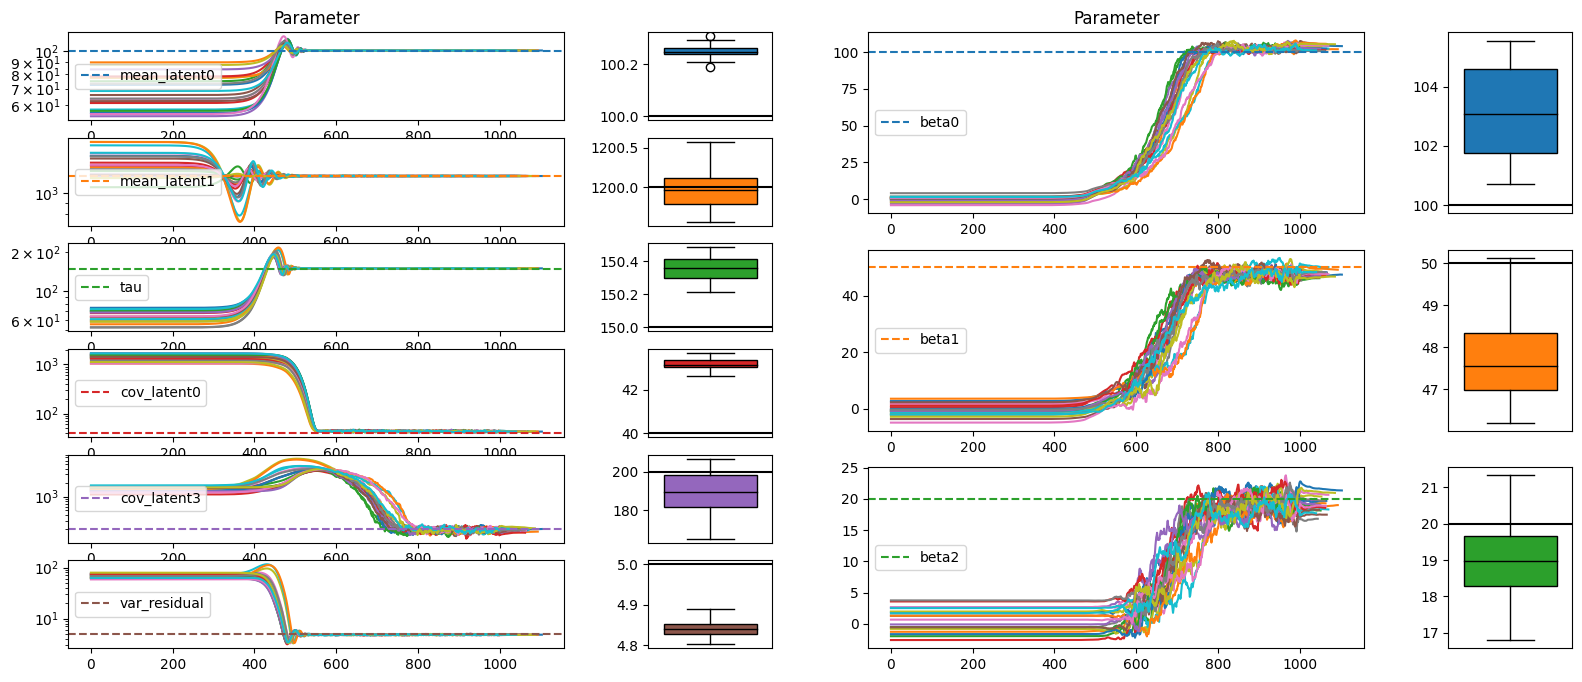

In [19]:
p_star = mynotCorrModel.new_params(
    mean_latent={"mu1": 100, "mu2": 1200},
    cov_latent=jnp.diag(jnp.array([40, 200])),
    tau=150,
    var_residual=5,
    beta=jnp.concatenate(
        [jnp.array([100, 50, 20]), jnp.zeros(shape=(mynotCorrModel.P - 3,))]
    ),
)
myobs, _ = mynotCorrModel.sample(p_star, jrd.PRNGKey(0))

multi_res = MultiRunRes(
    [
        one_estim(jrd.PRNGKey(key), mynotCorrModel, myobs, save_all=True)
        for key in range(20)
    ]
)
print(f"\nComputation time = {multi_res.chrono}")

fig = plot_estimation(multi_res)


Computation time = 0:00:20.657132


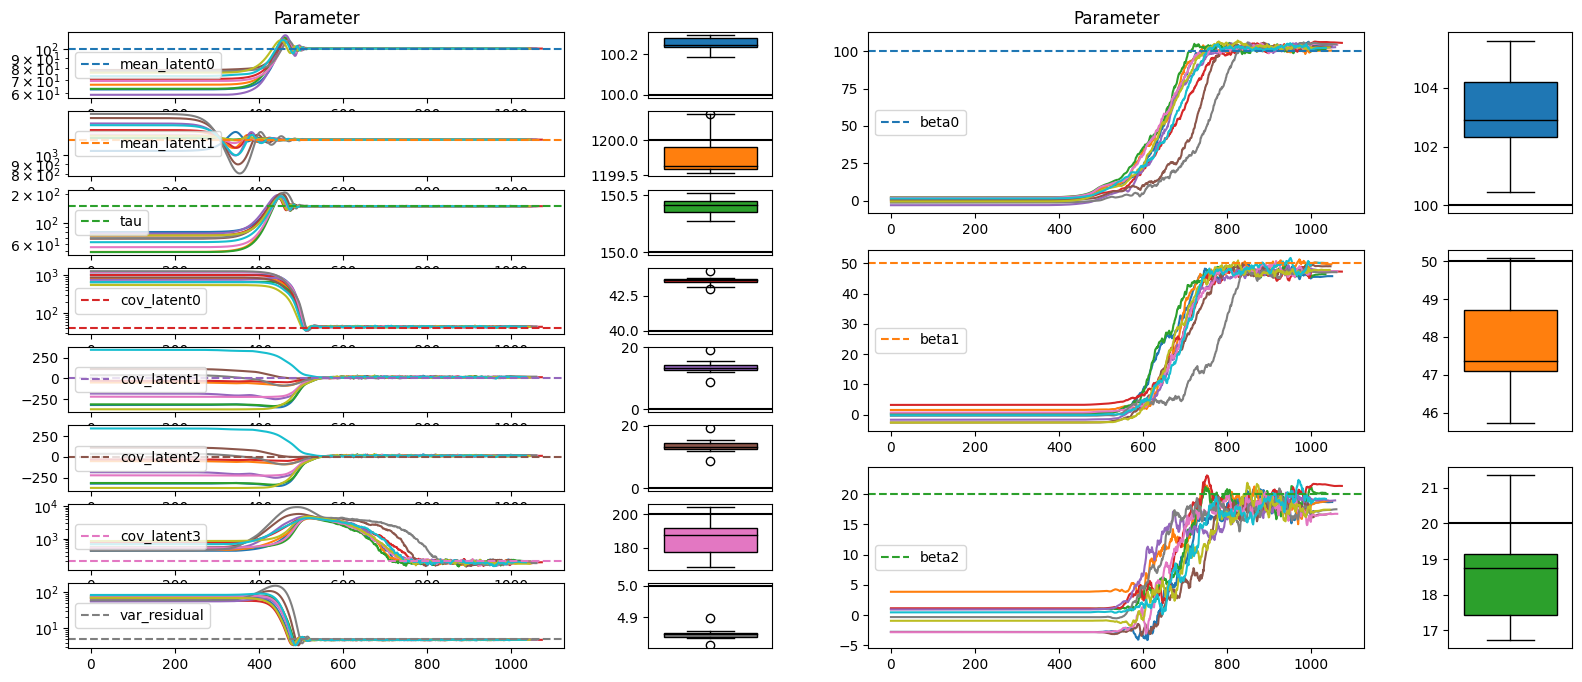

In [32]:
p_star = myModel.new_params(
    mean_latent={"mu1": 100, "mu2": 1200},
    cov_latent=jnp.array([[40, 0], [0, 200]]),
    tau=150,
    var_residual=5,
    beta=jnp.concatenate([jnp.array([100, 50, 20]), jnp.zeros(shape=(myModel.P - 3,))]),
)
myobs, _ = myModel.sample(p_star, jrd.PRNGKey(0))

multi_res = MultiRunRes(
    [one_estim(jrd.PRNGKey(key), myModel, myobs, save_all=True) for key in range(10)]
)
print(f"\nComputation time = {multi_res.chrono}")

fig = plot_estimation(multi_res, id_to_plot=[0, 1, 2, 3, 4, 5, 6, 7])

### Sans correlation entre les effets aléatoires

#### Correlation faible


Computation time = 0:00:24.410329


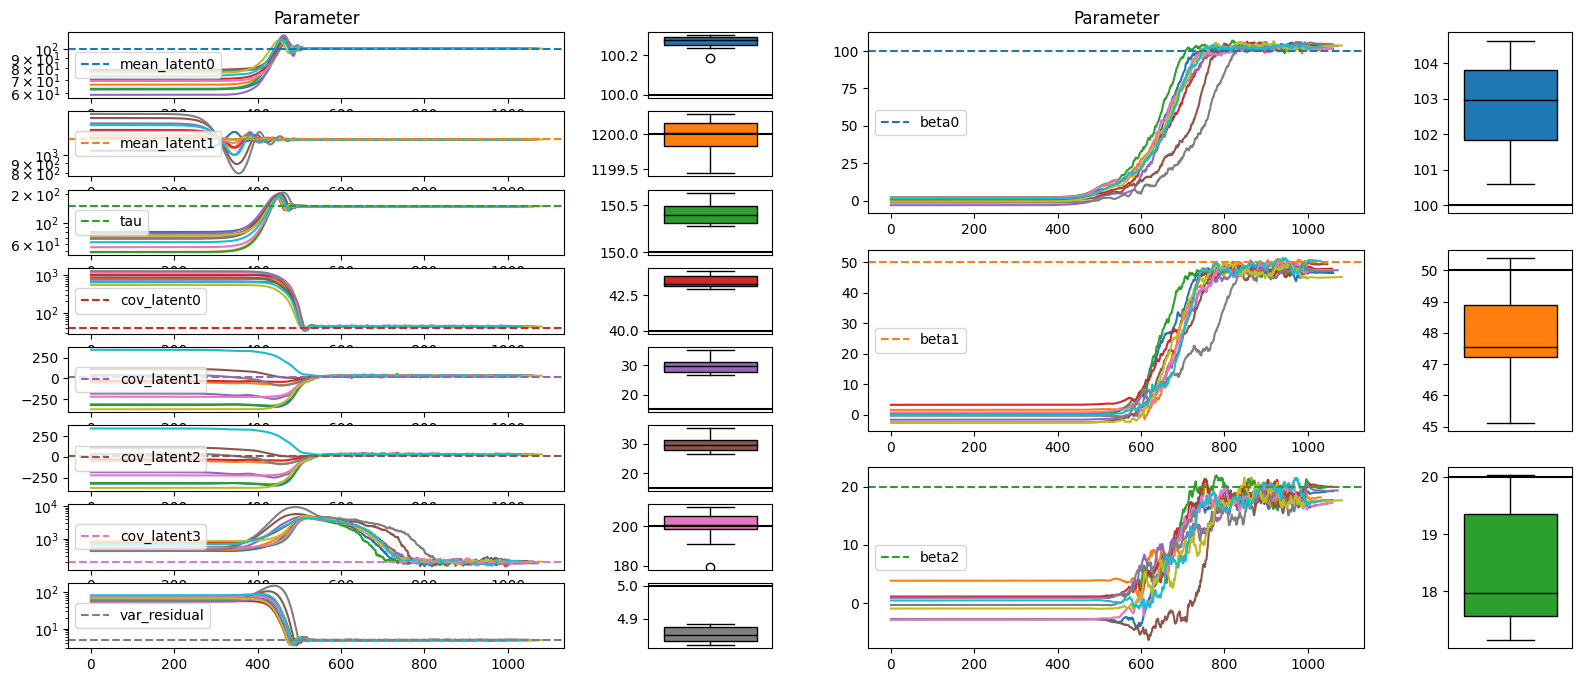

In [29]:
p_star = myModel.new_params(
    mean_latent={"mu1": 100, "mu2": 1200},
    cov_latent=jnp.array([[40, 15], [15, 200]]),
    tau=150,
    var_residual=5,
    beta=jnp.concatenate([jnp.array([100, 50, 20]), jnp.zeros(shape=(myModel.P - 3,))]),
)
myobs, _ = myModel.sample(p_star, jrd.PRNGKey(0))

multi_res = MultiRunRes(
    [one_estim(jrd.PRNGKey(key), myModel, myobs, save_all=True) for key in range(10)]
)
print(f"\nComputation time = {multi_res.chrono}")

fig = plot_estimation(multi_res, id_to_plot=[0, 1, 2, 3, 4, 5, 6, 7])

#### Correlation moyen


Computation time = 0:00:25.058565


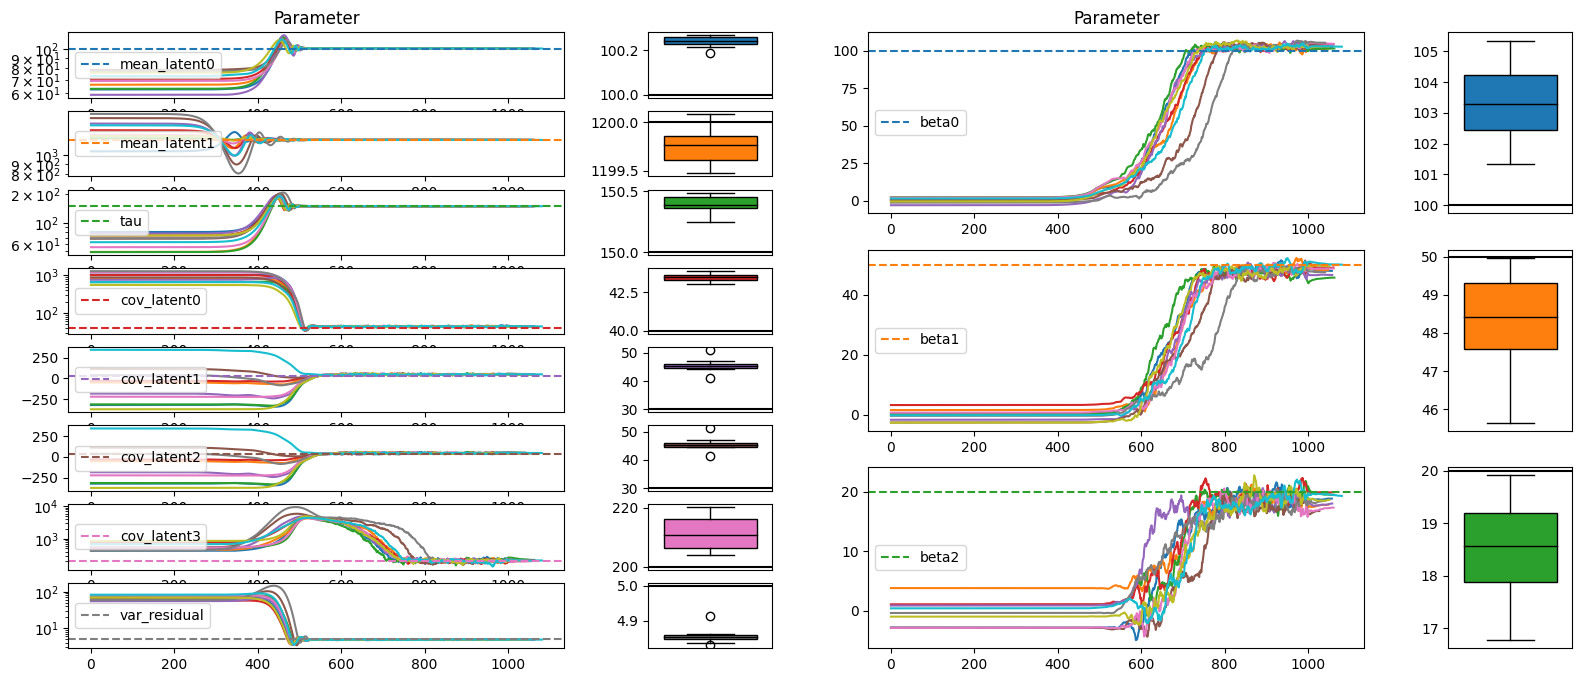

In [30]:
p_star = myModel.new_params(
    mean_latent={"mu1": 100, "mu2": 1200},
    cov_latent=jnp.array([[40, 30], [30, 200]]),
    tau=150,
    var_residual=5,
    beta=jnp.concatenate([jnp.array([100, 50, 20]), jnp.zeros(shape=(myModel.P - 3,))]),
)
myobs, _ = myModel.sample(p_star, jrd.PRNGKey(0))

multi_res = MultiRunRes(
    [one_estim(jrd.PRNGKey(key), myModel, myobs, save_all=True) for key in range(10)]
)
print(f"\nComputation time = {multi_res.chrono}")

fig = plot_estimation(multi_res, id_to_plot=[0, 1, 2, 3, 4, 5, 6, 7])

#### Correlation forte


Computation time = 0:00:20.633034


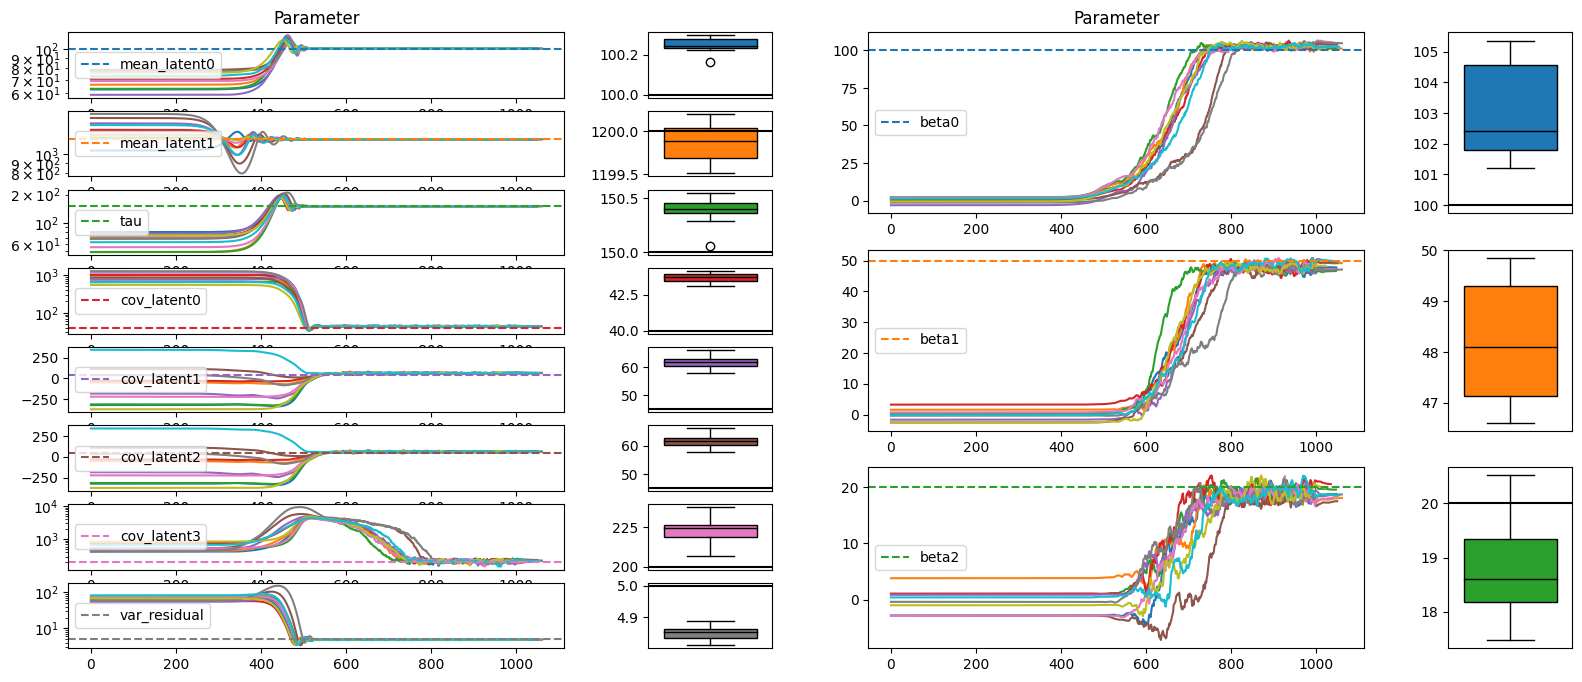

In [31]:
p_star = myModel.new_params(
    mean_latent={"mu1": 100, "mu2": 1200},
    cov_latent=jnp.array([[40, 45], [45, 200]]),
    tau=150,
    var_residual=5,
    beta=jnp.concatenate([jnp.array([100, 50, 20]), jnp.zeros(shape=(myModel.P - 3,))]),
)
myobs, _ = myModel.sample(p_star, jrd.PRNGKey(0))

multi_res = MultiRunRes(
    [one_estim(jrd.PRNGKey(key), myModel, myobs, save_all=True) for key in range(10)]
)
print(f"\nComputation time = {multi_res.chrono}")

fig = plot_estimation(multi_res, id_to_plot=[0, 1, 2, 3, 4, 5, 6, 7])

High Dimension

In [ ]:
# Run thos on a cluster
# res = multi_run(
#     jrd.PRNGKey(10),
#     lbd_set,
#     p_star_hd,
#     myHDModel,
#     nrun=1,
#     save_all=True,
# )

In [ ]:
sdgplt.get_ax(2, 2).plot(results[-1].likelihood)

In [ ]:
last_theta_estim = results[-1].last_theta[:, 1]

sdgplt.get_dataframe_results(
    last_theta_estim, myHDModel.hstack_params(p_star_hd), myHDModel.params_names
).style.format(
    {
        "real value": "{:.1f}".format,
        "mean": "{:.2f}".format,
        "variance": "{:.3f}".format,
        "rmse": "{:.4f}".format,
        "rrmse": "{:.1%}".format,
    }
)

In [ ]:
fig = sdgplt.figure(8, 8)
subfigs = fig.subfigures(2, 2, wspace=0.07)

for i, subfigsarr in enumerate(subfigs):
    for j, subfig in enumerate(subfigsarr):
        sdgplt.plot_reg_path(
            reg_res=results[-1][i * subfigs.shape[0] + j],
            dim_ld=myHDModel.DIM_LD,
            fig=subfig,
        )

In [ ]:
x = results.last_theta[:, :, -1, myHDModel.DIM_LD :]
print(jnp.isnan(x))
print(x.shape)

print(jnp.repeat(x.shape[-2], x.shape[0]))

y = jnp.tile(p_star_hd.beta, reps=30)
print(y.shape)

jnp.tile(p_star_hd.beta, reps=x.shape[:-1] + (1,)).shape

In [ ]:
def get_support_star(x, x_star):
    xx_star = jnp.tile(p_star_hd.beta, reps=x.shape[:-1] + (1,))
    return jnp.where(jnp.isnan(x), jnp.nan, xx_star != 0)


support_star = get_support_star(
    results.last_theta[:, :, -1, myHDModel.DIM_LD :], p_star_hd.beta
)
print(support_star.shape)


def get_support(x, x_star):
    if len(x.shape) > 1:
        return jnp.array([get_support(xx, x_star) for xx in x])

    return jnp.where(jnp.isnan(x), jnp.nan, x != 0)


multi_support = get_support(
    results.last_theta[:, :, -1, myHDModel.DIM_LD :], p_star_hd.beta
)
print(multi_support.shape)

In [ ]:
jnp.nansum(multi_support, axis=-1)

In [ ]:
lbd_set

In [ ]:
ax = sdgplt.get_ax(4, 4)

ax.hist(jnp.nansum(multi_support, axis=-1))

In [ ]:
all_component = jnp.nansum(jnp.abs(multi_support - support_star), axis=-1) == 0
first_component = (multi_support == support_star)[:, :, :3].mean(axis=-1) == 1
overselection = jnp.logical_and(first_component, jnp.logical_not(all_component))

score_support = jnp.array([all_component, overselection]).mean(axis=-1).T
print(score_support)

labels = ["Exact", "Over-selection"]
hatchs = ["", "/"]

ax = sdgplt.get_ax(5, 5)
for i in range(score_support.shape[0]):
    for j in range(len(labels)):
        ax.bar(
            scenarios_labels[i],
            score_support[i, j],
            label=labels[j],
            bottom=score_support[i, :j].sum(axis=0),
            color=f"C{0}",
            edgecolor="black",
            width=0.1,
            hatch=hatchs[j],
        )